# Airbnb Hotel Booking Analysis

## Load Dataset


In [63]:
# Load the Airbnb dataset
df = pd.read_excel("1776250134-P4-Airbnb Hotel Booking Analysis.xlsx")

print("Dataset loaded successfully.")
print("Rows and columns:", df.shape)
df.head()


Dataset loaded successfully.
Rows and columns: (102599, 26)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


## Data Understanding


In [52]:
# Basic dataset information
print("\nColumn names:")
print(df.columns.tolist())

print("\n\nData types and non-null counts:")
df.info()



Column names:
['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']


Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  str           
 4   host na

In [53]:
# Missing values and duplicate records
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:


,Missing Values
license,102597
house_rules,54843
last review,15893
reviews per month,15879
country,532
availability 365,448
minimum nights,409
host name,408
review rate number,326
calculated host listings count,319



Duplicate rows: 541


In [5]:
# Basic numerical summary
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,102599.0,NaN,NaN,NaN,29146234.52213,1001254.0,15085814.5,29136603.0,43201198.0,57367417.0,16257505.607309
NAME,102329,61280,Home away from home,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host id,102599.0,NaN,NaN,NaN,49254111474.328667,123600518.0,24583328475.0,49117739352.0,73996495817.0,98763129024.0,28538996644.374882
host_identity_verified,102310,2,unconfirmed,51200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host name,102191,13189,Michael,881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood group,102570,7,Manhattan,43792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,102583,224,Bedford-Stuyvesant,7937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,102591.0,NaN,NaN,NaN,40.728094,40.49979,40.68874,40.72229,40.76276,40.91697,0.055857
long,102591.0,NaN,NaN,NaN,-73.949644,-74.24984,-73.98258,-73.95444,-73.93235,-73.70522,0.049521
country,102067,1,United States,102067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning


In [6]:
# Make a copy so the original loaded data is preserved
df_clean = df.copy()

# Remove completely duplicate rows
before_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_duplicates = len(df_clean)

# Clean column names by removing accidental leading/trailing spaces
df_clean.columns = df_clean.columns.str.strip()

# Convert important numeric columns safely
numeric_columns = [
    "price",
    "service fee",
    "Construction year",
    "review rate number",
    "number of reviews",
    "calculated host listings count",
    "availability 365"
]

for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(
            df_clean[col].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False).str.strip(),
            errors="coerce"
        )

# Remove clearly invalid negative prices/service fees
for col in ["price", "service fee"]:
    if col in df_clean.columns:
        df_clean.loc[df_clean[col] < 0, col] = np.nan

print("Rows before cleaning:", before_rows)
print("Rows after duplicate removal:", after_duplicates)
print("Final shape:", df_clean.shape)


Rows before cleaning: 102599
Rows after duplicate removal: 102058
Final shape: (102058, 26)


In [7]:
# Missing-value treatment
# Keep the original data where possible and fill numeric analysis columns with their median.
for col in ["price", "service fee", "Construction year", "review rate number",
            "number of reviews", "calculated host listings count", "availability 365"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical columns used in the analysis with "Unknown"
for col in ["room type", "neighbourhood group", "host_identity_verified", "host name"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("Unknown")

# Use cleaned dataframe for the rest of the project
df = df_clean

print("Missing values after cleaning:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))


Missing values after cleaning:


,Missing Values
license,102056
house_rules,54538
last review,15832
reviews per month,15818
country,532
minimum nights,400
NAME,270
country code,131
instant_bookable,105
cancellation_policy,76


In [ ]:
# Final cleaning check
print("Final dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isna().sum().sum())


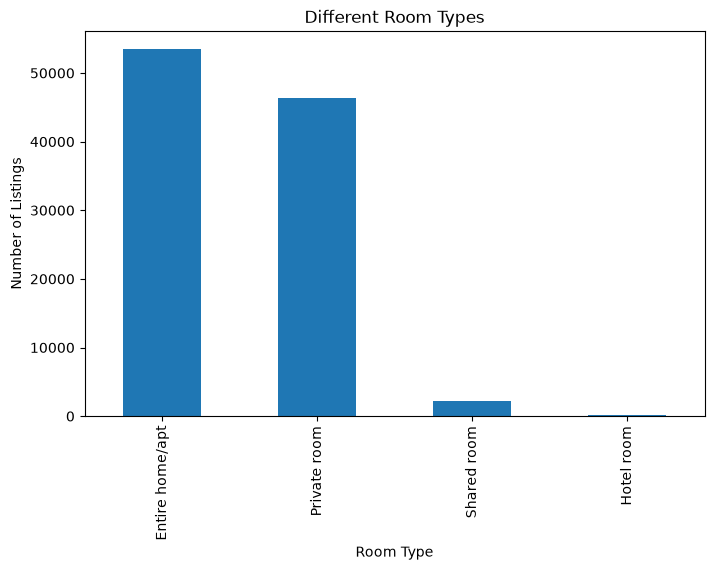

In [9]:
df["room type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Different Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.show()

In [10]:
df["neighbourhood group"].value_counts()

neighbourhood group
Manhattan        43557
Brooklyn         41630
Queens           13197
Bronx             2694
Staten Island      949
Unknown             29
brookln              1
manhatan             1
Name: count, dtype: int64

In [11]:
df["neighbourhood group"].value_counts().idxmax()

'Manhattan'

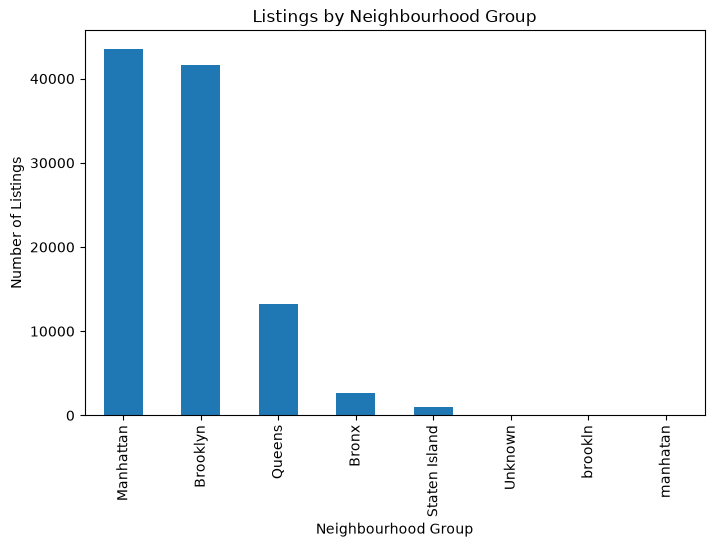

In [12]:
df["neighbourhood group"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.show()

In [14]:
df.groupby("neighbourhood group")["price"].mean().sort_values(ascending=False)

neighbourhood group
Unknown          657.206897
Queens           630.203986
Bronx            627.757610
Brooklyn         626.498607
Staten Island    623.993678
Manhattan        622.656863
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64

In [15]:
df.groupby("neighbourhood group")["price"].mean().idxmax()

'Unknown'

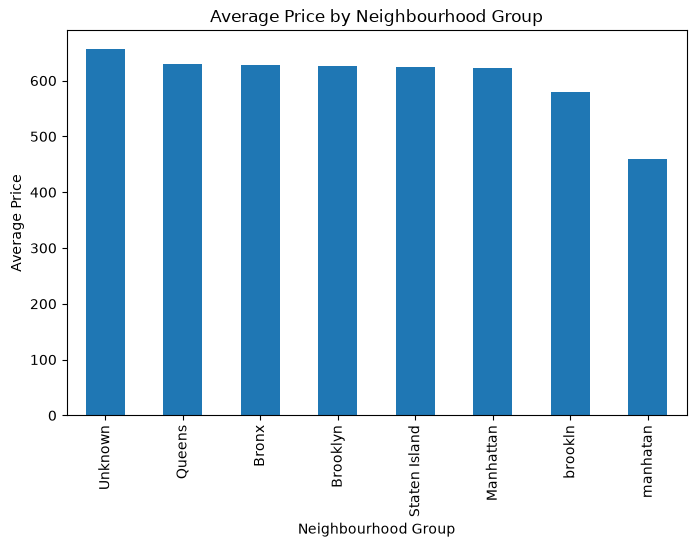

In [16]:
df.groupby("neighbourhood group")["price"].mean().sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.show()

In [17]:
df[["Construction year", "price"]].corr()

,Construction year,price
Construction year,1.0000,-0.0037
price,-0.0037,1.0000


In [18]:
correlation = df["Construction year"].corr(df["price"])

print("Correlation:", correlation)

Correlation: -0.0036996422974308824


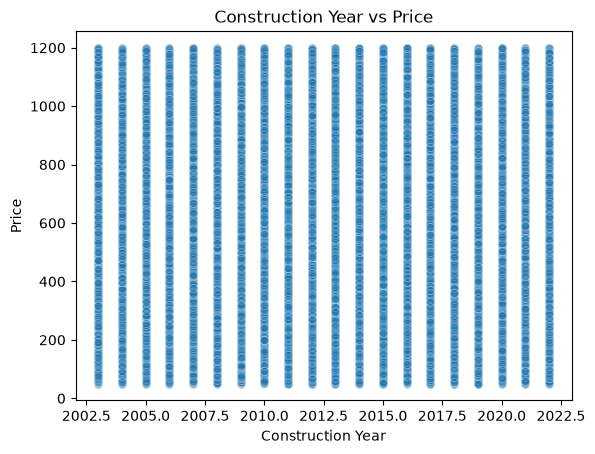

In [19]:
sns.scatterplot(
    data=df,
    x="Construction year",
    y="price",
    alpha=0.3
)

plt.title("Construction Year vs Price")
plt.xlabel("Construction Year")
plt.ylabel("Price")
plt.show()

In [20]:
df[
    ["host name", "calculated host listings count"]
].sort_values(
    "calculated host listings count",
    ascending=False
).head(10)

,host name,calculated host listings count
65123,Blueground,332.0
59511,Blueground,332.0
67033,Blueground,332.0
65271,Blueground,332.0
66258,Blueground,332.0
63538,Blueground,332.0
57898,Blueground,332.0
66463,Blueground,332.0
63337,Blueground,332.0
63596,Blueground,332.0


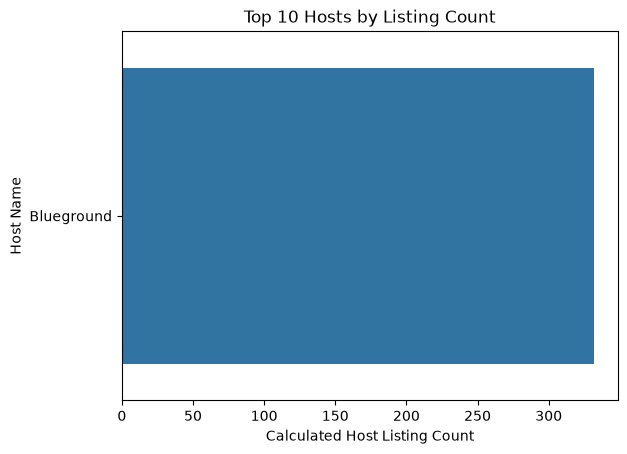

In [21]:
top10_hosts = df[
    ["host name", "calculated host listings count"]
].sort_values(
    "calculated host listings count",
    ascending=False
).head(10)

sns.barplot(
    data=top10_hosts,
    x="calculated host listings count",
    y="host name"
)

plt.title("Top 10 Hosts by Listing Count")
plt.xlabel("Calculated Host Listing Count")
plt.ylabel("Host Name")
plt.show()

In [22]:
df["host_identity_verified"].value_counts()

host_identity_verified
unconfirmed    50944
verified       50825
Unknown          289
Name: count, dtype: int64

In [23]:
df["positive_review"] = df["review rate number"] >= 4

In [24]:
df.groupby("host_identity_verified")["positive_review"].mean() * 100

host_identity_verified
Unknown        43.944637
unconfirmed    45.296796
verified       45.741269
Name: positive_review, dtype: float64

In [25]:
df.groupby("host_identity_verified")["review rate number"].mean()

host_identity_verified
Unknown        3.224913
unconfirmed    3.271141
verified       3.284899
Name: review rate number, dtype: float64

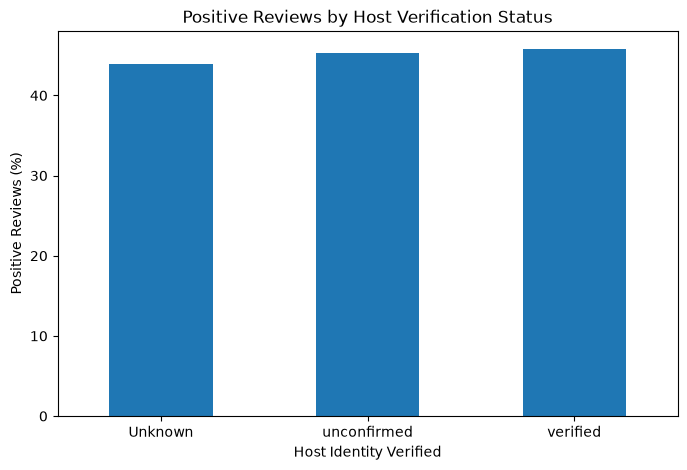

In [26]:
positive_reviews = (
    df.groupby("host_identity_verified")["positive_review"]
    .mean() * 100
)

positive_reviews.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Positive Reviews by Host Verification Status")
plt.xlabel("Host Identity Verified")
plt.ylabel("Positive Reviews (%)")
plt.xticks(rotation=0)
plt.show()

In [27]:
correlation = df["price"].corr(df["service fee"])

print("Price vs Service Fee Correlation:", correlation)

Price vs Service Fee Correlation: 0.9978247509610377


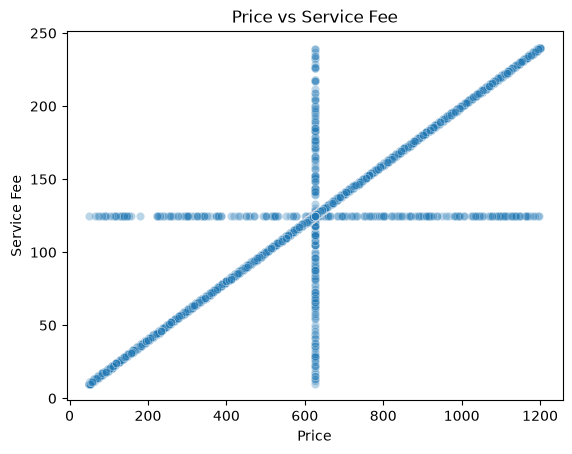

In [28]:
sns.scatterplot(
    data=df,
    x="price",
    y="service fee",
    alpha=0.3
)

plt.title("Price vs Service Fee")
plt.xlabel("Price")
plt.ylabel("Service Fee")
plt.show()

In [29]:
df["review rate number"].mean()

np.float64(3.2778616081051952)

In [30]:
df.groupby("neighbourhood group")["review rate number"].mean().sort_values(
    ascending=False
)

neighbourhood group
brookln          4.000000
Staten Island    3.401475
Queens           3.329469
Bronx            3.329250
Manhattan        3.275639
Brooklyn         3.257723
Unknown          3.206897
manhatan         3.000000
Name: review rate number, dtype: float64

In [31]:
df.groupby("room type")["review rate number"].mean().sort_values(
    ascending=False
)

room type
Hotel room         3.539130
Shared room        3.304348
Private room       3.280417
Entire home/apt    3.273990
Name: review rate number, dtype: float64

In [32]:
df.groupby(
    ["neighbourhood group", "room type"]
)["review rate number"].mean()

neighbourhood group  room type      
Bronx                Entire home/apt    3.344118
                     Private room       3.324567
                     Shared room        3.260870
Brooklyn             Entire home/apt    3.249280
                     Hotel room         3.857143
                     Private room       3.262940
                     Shared room        3.333738
Manhattan            Entire home/apt    3.274999
                     Hotel room         3.500000
                     Private room       3.276508
                     Shared room        3.253631
Queens               Entire home/apt    3.348964
                     Hotel room         3.750000
                     Private room       3.314315
                     Shared room        3.367688
Staten Island        Entire home/apt    3.327004
                     Private room       3.473913
                     Shared room        3.533333
Unknown              Entire home/apt    3.181818
                     Private roo

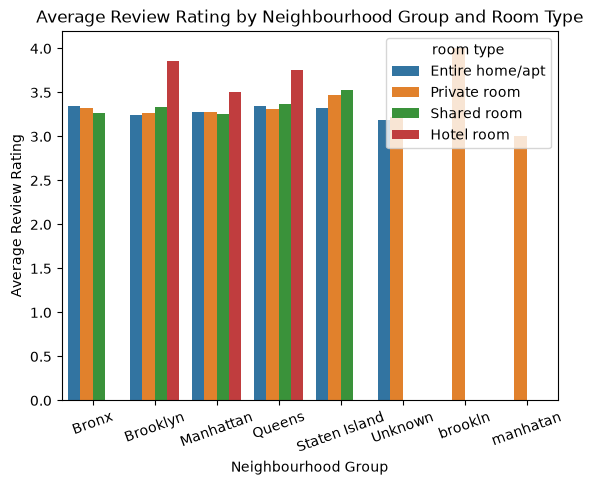

In [33]:
rating_data = (
    df.groupby(
        ["neighbourhood group", "room type"]
    )["review rate number"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=rating_data,
    x="neighbourhood group",
    y="review rate number",
    hue="room type"
)

plt.title("Average Review Rating by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Review Rating")
plt.xticks(rotation=20)
plt.show()

In [34]:
df[
    [
        "calculated host listings count",
        "availability 365"
    ]
].corr()

,calculated host listings count,availability 365
calculated host listings count,1.000000,0.158685
availability 365,0.158685,1.000000


In [35]:
correlation = df[
    "calculated host listings count"
].corr(
    df["availability 365"]
)

print("Correlation:", correlation)

Correlation: 0.15868482854114047


In [36]:
df["host_listing_group"] = pd.cut(
    df["calculated host listings count"],
    bins=[0, 1, 5, 20, np.inf],
    labels=[
        "1 Listing",
        "2-5 Listings",
        "6-20 Listings",
        "21+ Listings"
    ]
)

In [37]:
df.groupby(
    "host_listing_group",
    observed=True
)["availability 365"].mean()

host_listing_group
1 Listing        114.718301
2-5 Listings     158.939028
6-20 Listings    233.301067
21+ Listings     242.365858
Name: availability 365, dtype: float64

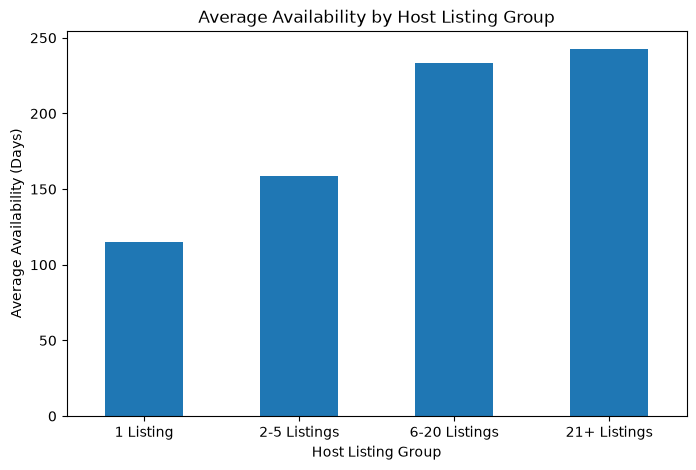

In [38]:
availability_data = (
    df.groupby(
        "host_listing_group",
        observed=True
    )["availability 365"]
    .mean()
)

availability_data.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Availability by Host Listing Group")
plt.xlabel("Host Listing Group")
plt.ylabel("Average Availability (Days)")
plt.xticks(rotation=0)
plt.show()